# $$UnSupervised-Learning$$

Supervised Learning
- labels
- Labelled data ---> train models to learn patterns ---> prediction
- 
- Interview focus is on:
    - how different models can be used for different situations
    - e.g. for binary classification the best kind of model one can use is Logistic Regression
        - spam detection --- ML 
        - if you have a big arsenal of models at hand
    - 
    - Read about which model is used for what use case
    - which models are heavy on the hardware e.g. random forest - ensemble is a combination of multiple models
    - or time consuming
    - which models are more optimized for convergence - finding the global minimum of error percentage
    - 
- 

![](https://i.vas3k.blog/7w1.jpg)

### Unsupervised Learning
- is the type of ML in which we have data that is unlabelled
- 
- How to spot Anomalies
    - Detect Frauds
    - Check network vulnerabilities - connection request - weird ---
    - Hacking pattern will be different
    - 
    - Document clustering === organize your data
- Common examples: 
    - Customer segregation - high spending etc
    - Fraud Detection - find a anomalous record
    - Can use this to reduce data dimensions or number of columns ---> Dimensionality Reduction

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns



In [65]:
df_iris = sns.load_dataset('iris')

df_iris_UL = df_iris.drop('species', axis = 1)

df_iris_UL.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


- if i give to you a list of inputs ---> sl, sw, pl, pw --->
- will you be able to tell me which specie it is?
- 
- there is no species ---> how can a model learn from such data?
- the model cannot know what specie it is BUT
    - models are really good at finding patterns in the data
    - 

- UNSUPERVISED LEARNING - models find the patterns, and assign the clusters ( group ) to the input data
- The only difference is, the model does not know which cluster is what ---> eg. is it setosa, or virginica or versicolor


#### Clustering
- creating clusters out of unlabelled data
    - un named clusted
    - 
- algorithms:
1. K-Means Clustering
2. Hierarchical Clustering - Agglomerative - Divisive
3. DBSCAN - density based spatial clustering

In [66]:
# sns.pairplot(df_iris_UL)

### 1. K-Means Clustering

- partitions data into k distinct clusters
- each has a centroid - average of all the points in the cluster
- 

- 
- Steps:
    1. **Initialization** - randomly `k` points are made into a cluster
    2. **Assignment** - assign each data point to the nearest cluster
    3. **Update** - Recacluate the centroid of the clusters - there would be `movement` of clusters due to new points included
    4. **Repeat** the process untill centroid stabilize
    5. **Convergence** - When the centroid movement stops or centroids stabilize



![](https://i.vas3k.blog/7w6.jpg)

- Initialization:
    1. Random initialization (Naive Initialization): K random data points are defined as centroids
    2. KMeans++ : Centroidsa are spread out more evenly
        - first centroid - placed randomly
        - rest are placed based on the maximum squared distance
        - idea is to push centroids as far as possible from each other

- 

The centroid is defined as the mean position of all points in a geometric figure
![](https://d138zd1ktt9iqe.cloudfront.net/media/seo_landing_files/centroid-formula-1620901411.png)

<Axes: xlabel='petal_length', ylabel='petal_width'>

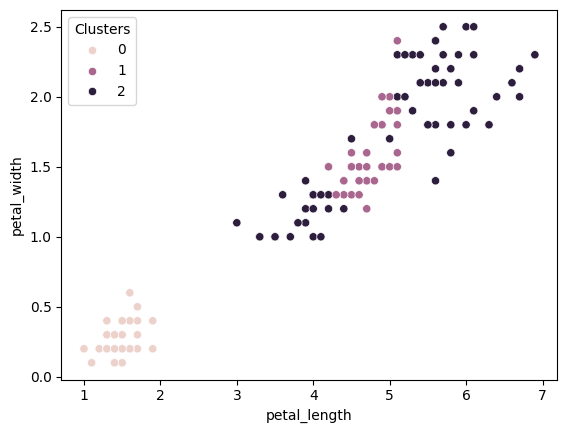

In [85]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters = 3, init = "random", random_state = 42)

df_iris_UL['Clusters'] = kmeans.fit_predict(df_iris_UL)
df_iris_UL.head()

sns.scatterplot(data= df_iris_UL, x = df_iris_UL.petal_length, y = df_iris_UL.petal_width, hue= 'Clusters')
# df_iris_UL.Clusters.value_counts()

In [68]:
df_iris_UL

,sepal_length,sepal_width,petal_length,petal_width,Clusters
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,0
148,6.2,3.4,5.4,2.3,0


In [69]:
# scale all the features --- normalization
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler()
scaler = StandardScaler()

df_iris_UL_scaled = scaler.fit_transform(df_iris_UL)

In [70]:
# --- model on scaled data
df_iris_UL['Clusters_2'] = kmeans.fit_predict(df_iris_UL_scaled)
df_iris_UL.head()

,sepal_length,sepal_width,petal_length,petal_width,Clusters,Clusters_2
0,5.1,3.5,1.4,0.2,1,2
1,4.9,3.0,1.4,0.2,1,2
2,4.7,3.2,1.3,0.2,1,2
3,4.6,3.1,1.5,0.2,1,2
4,5.0,3.6,1.4,0.2,1,2


In [71]:
# check the accuracy of this model as well

df_iris_UL.Clusters_2.value_counts()

Clusters_2
0    61
2    50
1    39
Name: count, dtype: int64

<Axes: xlabel='petal_length', ylabel='petal_width'>

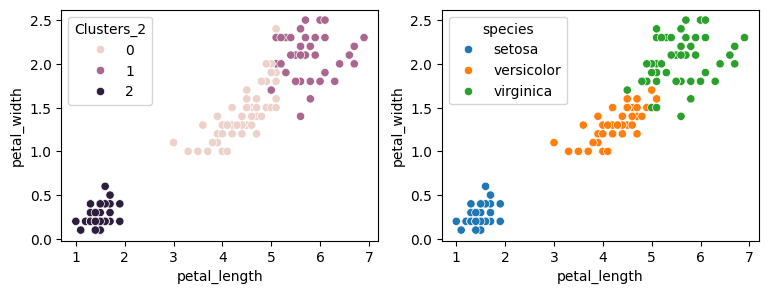

In [72]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize= (9,3))

sns.scatterplot(data= df_iris_UL, x = df_iris_UL.petal_length, y = df_iris_UL.petal_width, hue= 'Clusters_2', ax= ax[0])

sns.scatterplot(data= df_iris, x = df_iris.petal_length, y = df_iris.petal_width, hue= 'species', ax= ax[1])

### Exercise:
- compare the clusters of KMeans vs the real ones using two scatterplots on a suplot
Create two plots side by side, one for the original data that had labels and one with the data labels that were created by KMeans clustering algorithm

<Axes: xlabel='petal_length', ylabel='petal_width'>

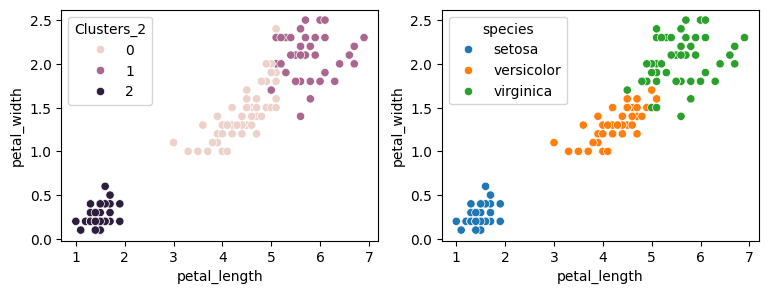

In [73]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize= (9,3))

sns.scatterplot(data= df_iris_UL, x = df_iris_UL.petal_length, y = df_iris_UL.petal_width, hue= 'Clusters_2', ax= ax[0])

sns.scatterplot(data= df_iris, x = df_iris.petal_length, y = df_iris.petal_width, hue= 'species', ax= ax[1])

### Ideal K for any data - where number of clusters we do not know
- We knew there are 3 clusters
    - what if we do not know the number of clusters in our data

1. Elbow Method
    - you take idea of intertia (cost)
    - inertia - Sum of squared distances of each `data points` to the `centroid`
    - Within Cluster Sum of Squares (WCSS)
    - 
    - we plot K 
    - as K increases the inertia decreases 
    - where the decrease is sharp / ELBOW --> preferd number of K
2. Silhoutte Method

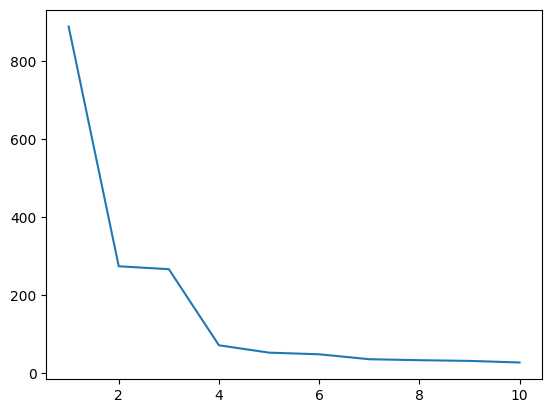

In [74]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters= i, init = "k-means++", random_state = 42)
    kmeans.fit(df_iris_UL)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)

- K means thinks 2 is the ideal number of clusters in the data
    - it actually seems fair as well when we look at the data
    - there is a lot overlap in the versicolor and virginica
- 

## Learn about other clustering algorithms - 
- Hierarchical
- DBSCAN


### GO through this:

## Hierarchical Clustering
1. Agglomerative Clustering
    - data points, treat them a individual clusters
    - calcualte distance between clusters
    - group up the nearest ones
    - keep doing it untill you have one unified supercluster
![](https://www.janbasktraining.com/tutorials/uploads/images/Agglomerative_Clustering__1.jpg)
![](https://i.ytimg.com/vi/XJ3194AmH40/maxresdefault.jpg)

2. Divisive Clustering
    - top down approach
    - cluster, you break it down, based on how far each broken cluster is
![](https://dataaspirant.com/wp-content/uploads/2020/12/17-Hierarchical-Divisive-Clustering.png)


Steps for agglomerative clustering:
- Key Steps:

1. Initialize – Treat each point as an individual cluster.
2. Compute Distances – Calculate pairwise distances between clusters.
3. Merge Closest Clusters – Based on the linkage criterion.
4. Update Distances – Recalculate distances after each merge.
5. Repeat – Continue until the desired number of clusters or threshold is reached.
6. Visualize – Use a **dendrogram** to interpret cluster relationships.

In [86]:
# just an example
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering

# scipy
from scipy.cluster.hierarchy import dendrogram, linkage

# Sample data: Spending on two products
data = np.array([
[500, 200],
[550, 180],
[600, 250],
[150, 80],
[200, 100],
[650, 300]
])

# Agglomerative Clustering with 2 clusters
model = AgglomerativeClustering(n_clusters=2, linkage='ward')
clusters = model.fit_predict(data)
print("Cluster assignments:", clusters)

Cluster assignments: [0 0 0 1 1 0]


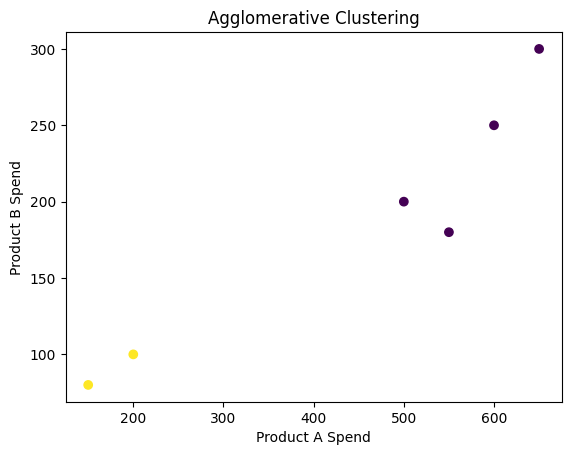

In [87]:
# Scatter plot of clusters
plt.scatter(data[:, 0], data[:, 1], c=clusters, cmap='viridis')
plt.xlabel("Product A Spend")
plt.ylabel("Product B Spend")
plt.title("Agglomerative Clustering")
plt.show()

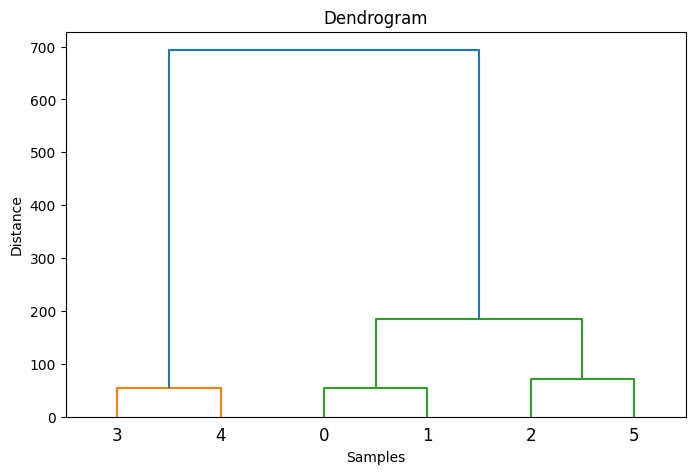

In [88]:
# Dendrogram
Z = linkage(data, method='ward')
plt.figure(figsize=(8, 5))

dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

#### Implement hierarchical clustering on real life datasets as well
- let's implement this on iris



In [ ]:
# model
from sklearn.cluster import AgglomerativeClustering

# dendogram visualizatino requirements
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
# agglomerative clustering
hc_model = AgglomerativeClustering(n_clusters= 3, linkage= 'ward')
hc_clusters = hc_model.fit_predict(df)

df['hc_clusters'] = hc_clusters
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clusters,hc_clusters
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


In [ ]:
# observe these visuals as well
# sns.pairplot(df, hue= clusters)

#### Dendograms help us visualise our hierarchical clustering

In [ ]:
df_without_clusters = df.drop(['clusters','hc_clusters'], axis = 1)
df_without_clusters.head(0)
df_without_clusters.shape

(150, 4)

In [ ]:
df_without_clusters.shape


(150, 4)

In [ ]:
labels = [x for x in range(0,150)] # list comprehension
labels = [x  if x% 2== 0 else '' for x in range(0,150)]

In [ ]:
# for all the 150 records, let's print their class names as well
labels012 = iris.target # instead of indexes we will have labels
# we will manually say, if 0 ===> setosa, if 1 ===> virginica, if 2 ===> versicolor

labels = [iris.target_names[label] if index % 2 == 0 else '' for index, label in enumerate(labels012)]

# for index, label in enumerate(labels012): # indexed list of things
#     print(index, label) # index ===> 0 or 1 or 2

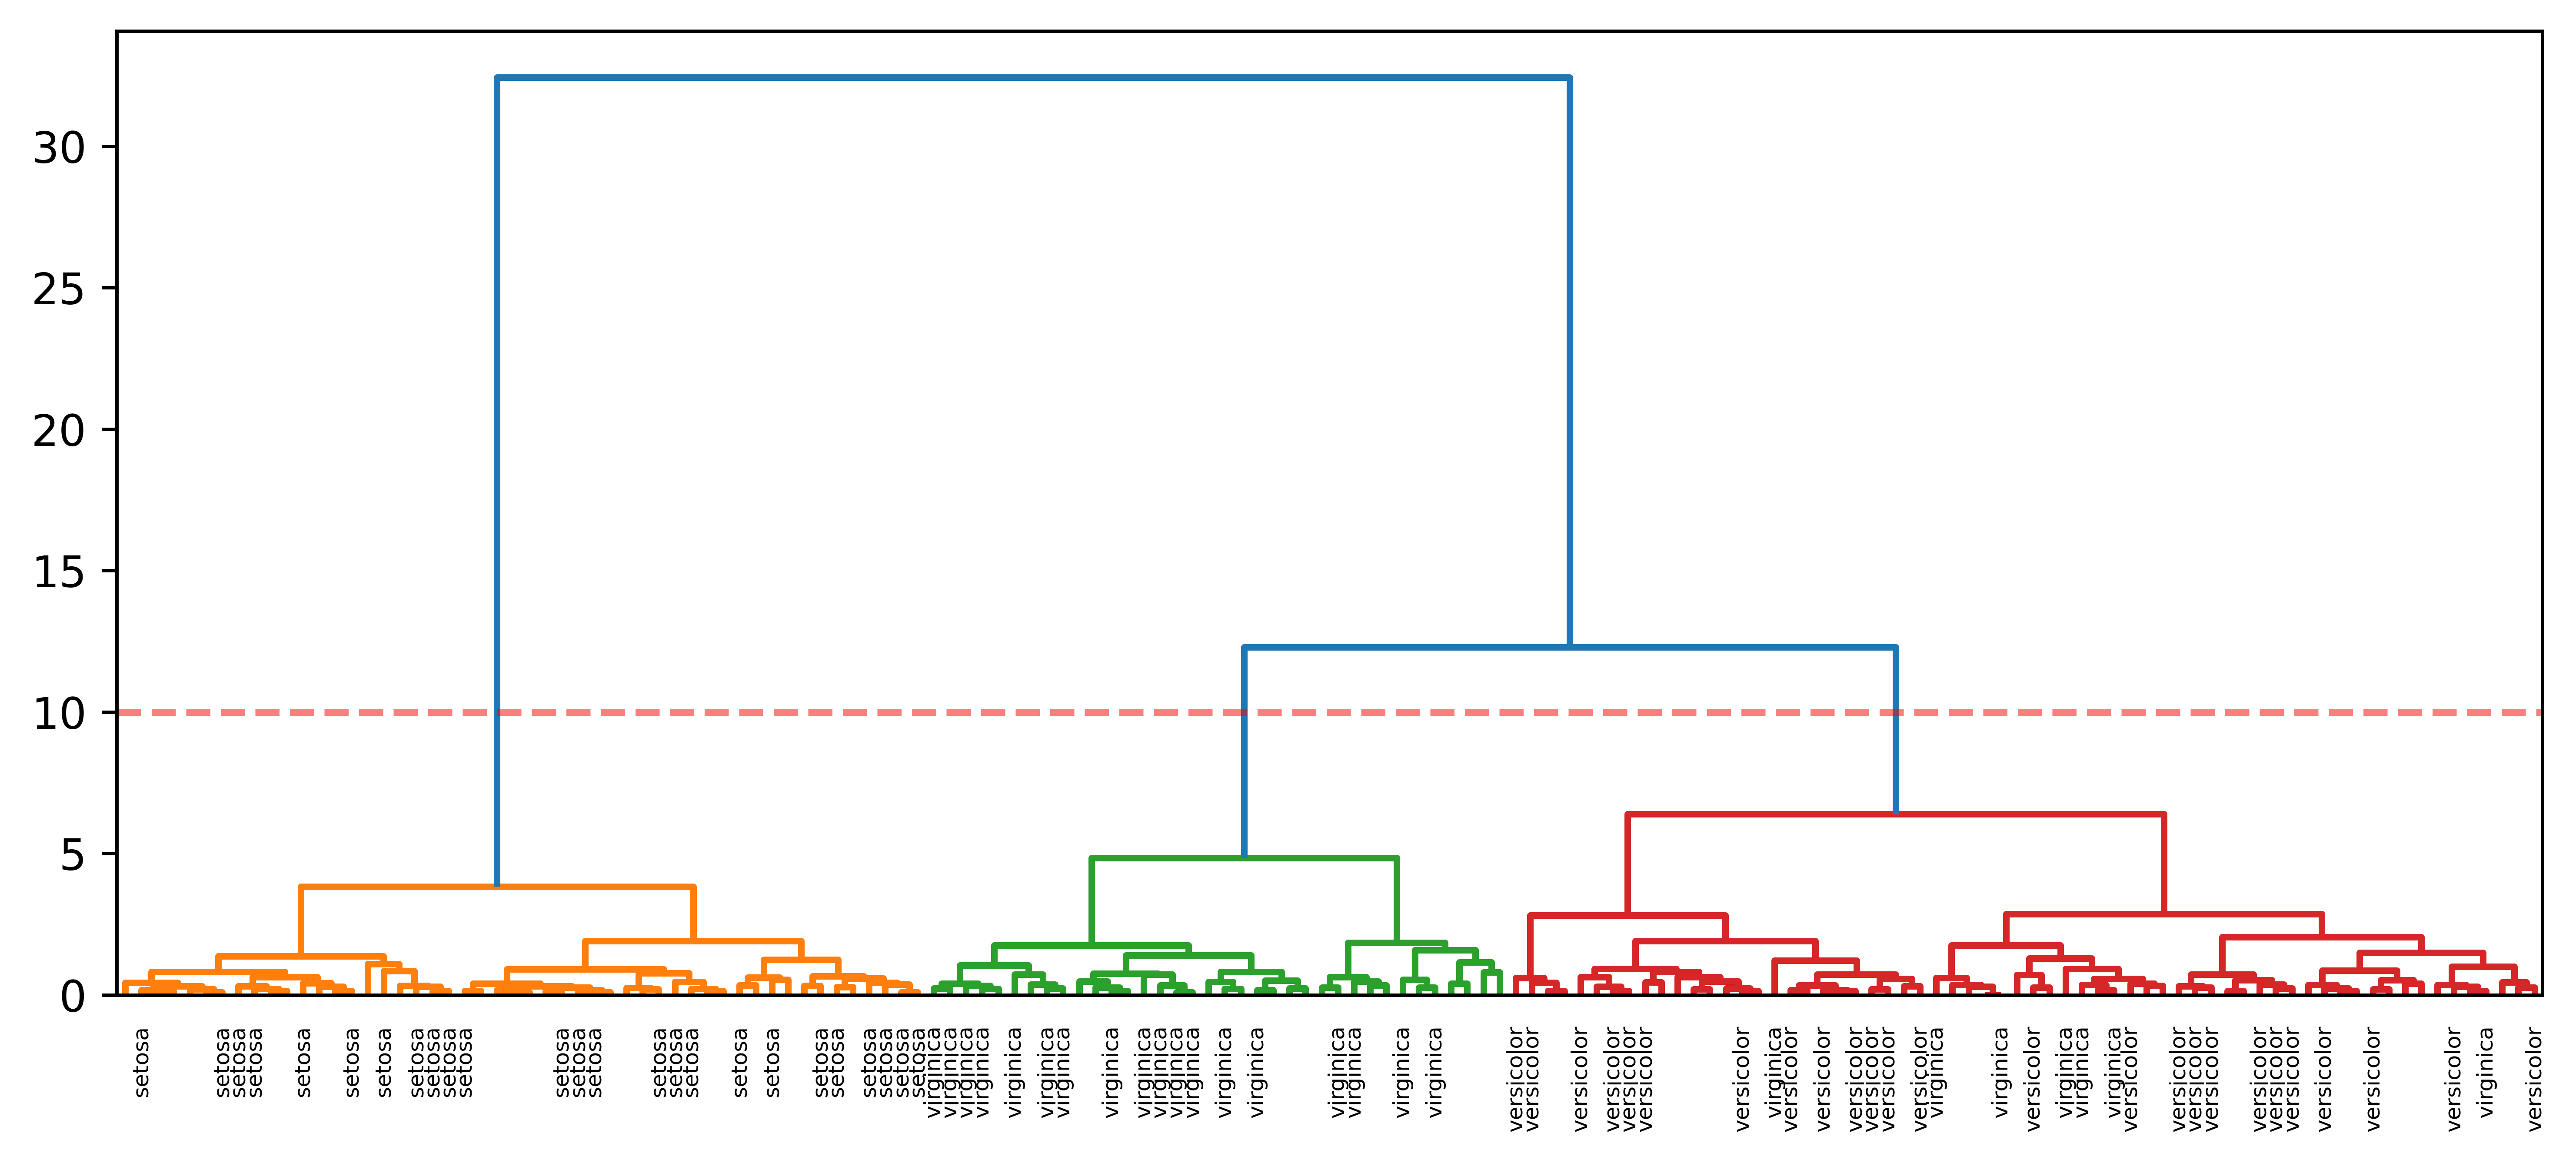

In [ ]:
# dendogram
plt.figure(figsize= (10,4), dpi = 720)
Z = linkage(df_without_clusters, method='ward')
dendrogram(Z, color_threshold = 7, labels = labels)
plt.axhline(y = 10, color  = 'r', linestyle = '--', alpha = 0.5) # axh is the horizontal line 
plt.show()

#### Homework:
- Read the cells below, and try to learn what they are covering
- 

### Evaluation of Clustering Results:

1. **Silhouette Score:**
- Measure how similar an object is to its own cluster
- Range: -1 to 1
- Closer to 1, means that point is far from its neighbouring clusters
- Closer to 0, its at the boundary
- 
- **Higher** is better

2. **Davies- Bouldin Index**
- measures the average similarity between clusters
- if similarity is less between clusters, it means they are very different, and farrrrrrrrrrr
- **Lower** values will indicate better clustering

3. **Adjusted Rand Index ARI**
- Compare clustering performance with a known truth
- if you have access to ground truth labels ------- have a labelled Dataset
- look at the similarity --- predicted clusters, and actual labels
- 
- **Higher** is better

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

hcsc = silhouette_score(iris.data, df.hc_clusters)

hcdbs = davies_bouldin_score(iris.data, df.hc_clusters)

hcari = adjusted_rand_score(iris.target, df.hc_clusters)

In [ ]:
knnsc = silhouette_score(iris.data, df.clusters)

knnsc = davies_bouldin_score(iris.data, df.clusters)

knnsc = adjusted_rand_score(iris.target, df.clusters)

In [ ]:
print("-"*10,"Scores of Agglomerative Clustering", "-"*10)

print("Clustering Scores ---------->         Hierarchical     KNN")
print(f"shillouete Score: ---------->     {hcsc:.2f}             {knnsc:.2f}")
print(f"Davies Bouldin Score: ------>     {hcdbs:.2f}             {knnsc:.2f}")
print(f"ARI Score: ----------------->    {hcari:.2f}             {knnsc:.2f}")

---------- Scores of Agglomerative Clustering ----------
Clustering Scores ---------->         Hierarchical     KNN
shillouete Score: ---------->     0.55             0.73
Davies Bouldin Score: ------>     0.66             0.73
ARI Score: ----------------->    0.73             0.73


#### Association

#### Dimensionality Reduction